In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
exercise_angles_dataset = pd.read_csv('/content/drive/MyDrive/aigymate/exercise_angles.csv')
exercise_angles_dataset

,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label
0,left,10.639208,174.466813,174.785143,179.848140,179.419276,90.0,90.0,90.0,90.0,90.0,Jumping Jacks
1,left,10.590342,174.428706,174.765042,179.775215,179.386147,90.0,90.0,90.0,90.0,90.0,Jumping Jacks
2,left,10.546746,174.489431,174.785790,179.660017,179.333710,90.0,90.0,90.0,90.0,90.0,Jumping Jacks
3,left,10.487682,174.614913,174.759542,179.614223,179.313926,90.0,90.0,90.0,90.0,90.0,Jumping Jacks
4,left,10.412107,174.758503,174.737721,179.570564,179.298805,90.0,90.0,90.0,90.0,90.0,Jumping Jacks
...,...,...,...,...,...,...,...,...,...,...,...,...
31028,left,12.723974,81.226330,149.356832,154.358415,178.103121,90.0,90.0,90.0,90.0,-90.0,Russian twists
31029,left,9.080920,82.486551,148.100509,152.680540,178.625318,90.0,90.0,90.0,90.0,-90.0,Russian twists
31030,left,4.118076,85.164707,148.329461,152.458288,178.605852,90.0,90.0,90.0,90.0,-90.0,Russian twists
31031,left,0.558065,89.419330,146.742440,149.930600,179.604753,90.0,90.0,90.0,90.0,-90.0,Russian twists


In [8]:
features = []

for column in exercise_angles_dataset.columns:
    features.append(column)

targets = features.pop()

In [9]:
del features[0]
features

['Shoulder_Angle',
 'Elbow_Angle',
 'Hip_Angle',
 'Knee_Angle',
 'Ankle_Angle',
 'Shoulder_Ground_Angle',
 'Elbow_Ground_Angle',
 'Hip_Ground_Angle',
 'Knee_Ground_Angle',
 'Ankle_Ground_Angle']

In [10]:
targets

'Label'

In [11]:
label_encoder = LabelEncoder()
exercise_angles_dataset[targets] = label_encoder.fit_transform(exercise_angles_dataset[targets])

exercise_predictors = exercise_angles_dataset[features].values
exercise_categories = exercise_angles_dataset[targets].values
exercise_predictors_train, exercise_predictors_test, exercise_categories_train, exercise_categories_test = train_test_split(exercise_predictors, exercise_categories, test_size = 0.2, random_state = 42)

In [13]:
import tensorflow as tf
import numpy as np

# Reshape for CNN
X_train_cnn = exercise_predictors_train.reshape(
    exercise_predictors_train.shape[0],
    exercise_predictors_train.shape[1],
    1
)

# CNN Model
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(X_train_cnn.shape[1],1)),

    tf.keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(np.unique(exercise_categories)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Best model checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/aigymate/best_cnn_model.h5",          # file name
    monitor="val_accuracy",       # metric to monitor
    save_best_only=True,          # only save best model
    mode="max",                   # maximize accuracy
    verbose=1
)

# Train model
history = model.fit(
    X_train_cnn,
    exercise_categories_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint]
)

Epoch 1/50
615/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5753 - loss: 1.6003
Epoch 1: val_accuracy improved from -inf to 0.80467, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5765 - loss: 1.5923 - val_accuracy: 0.8047 - val_loss: 0.4814
Epoch 2/50
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7938 - loss: 0.5395
Epoch 2: val_accuracy improved from 0.80467 to 0.86508, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7939 - loss: 0.5394 - val_accuracy: 0.8651 - val_loss: 0.4005
Epoch 3/50
613/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8361 - loss: 0.4516
Epoch 3: val_accuracy did not improve from 0.86508
621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8362 - loss: 0.4515 - val_accuracy: 0.8588 - val_loss: 0.3898
Epoch 4/50
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8552 - loss: 0.3978
Epoch 4: val_accuracy improved from 0.86508 to 0.87958, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8552 - loss: 0.3978 - val_accuracy: 0.8796 - val_loss: 0.3344
Epoch 5/50
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8689 - loss: 0.3675
Epoch 5: val_accuracy did not improve from 0.87958
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8689 - loss: 0.3675 - val_accuracy: 0.8792 - val_loss: 0.3369
Epoch 6/50
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8764 - loss: 0.3436
Epoch 6: val_accuracy improved from 0.87958 to 0.89005, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8764 - loss: 0.3436 - val_accuracy: 0.8901 - val_loss: 0.3236
Epoch 7/50
614/621 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8805 - loss: 0.3290
Epoch 7: val_accuracy improved from 0.89005 to 0.89529, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


...

621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9289 - loss: 0.1886 - val_accuracy: 0.9382 - val_loss: 0.2259
Epoch 26/50
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9342 - loss: 0.1834
Epoch 26: val_accuracy improved from 0.93818 to 0.94805, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9342 - loss: 0.1834 - val_accuracy: 0.9480 - val_loss: 0.2158
Epoch 27/50
613/621 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9377 - loss: 0.1747
Epoch 27: val_accuracy did not improve from 0.94805
621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9377 - loss: 0.1747 - val_accuracy: 0.9331 - val_loss: 0.2416
Epoch 28/50
613/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9363 - loss: 0.1749
Epoch 28: val_accuracy improved from 0.94805 to 0.94865, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9363 - loss: 0.1750 - val_accuracy: 0.9487 - val_loss: 0.2292
Epoch 29/50
620/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9368 - loss: 0.1753
Epoch 29: val_accuracy did not improve from 0.94865
621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9368 - loss: 0.1753 - val_accuracy: 0.9156 - val_loss: 0.2581
Epoch 30/50
615/621 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9365 - loss: 0.1747
Epoch 30: val_accuracy did not improve from 0.94865
621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9365 - loss: 0.1747 - val_accuracy: 0.9313 - val_loss: 0.2384
Epoch 31/50
612/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9433 - loss: 0.1607
Epoch 31: val_accuracy did not improve from 0.94865
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9433 - loss: 0.1608 - val_accuracy: 0.9414 - val_loss: 0.2183
Epoch 32/50
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9395 - loss: 0.1675
Epoch 32: val_accuracy did n

621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9492 - loss: 0.1331 - val_accuracy: 0.9495 - val_loss: 0.2375
Epoch 48/50
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.1294
Epoch 48: val_accuracy did not improve from 0.94946
621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9534 - loss: 0.1294 - val_accuracy: 0.9398 - val_loss: 0.2762
Epoch 49/50
615/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9521 - loss: 0.1346
Epoch 49: val_accuracy improved from 0.94946 to 0.95308, saving model to /content/drive/MyDrive/aigymate/best_cnn_model.h5


621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9521 - loss: 0.1346 - val_accuracy: 0.9531 - val_loss: 0.2250
Epoch 50/50
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.1268
Epoch 50: val_accuracy did not improve from 0.95308
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9563 - loss: 0.1269 - val_accuracy: 0.9478 - val_loss: 0.2141


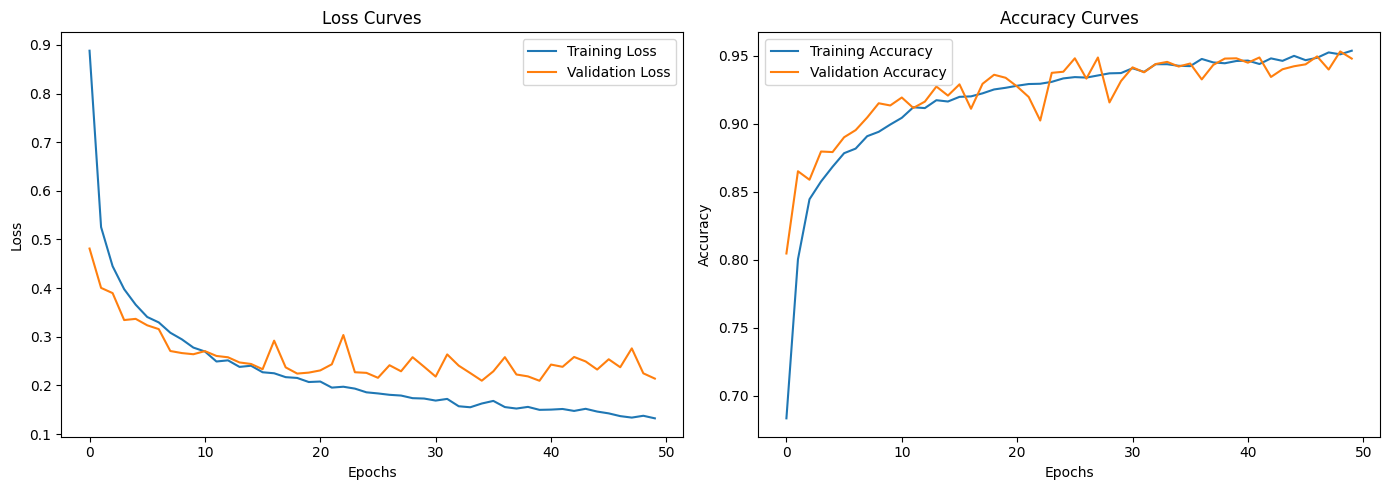

In [14]:
plt.figure(figsize = (14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
X_test_cnn = exercise_predictors_test.reshape(
    exercise_predictors_test.shape[0],
    exercise_predictors_test.shape[1],
    1
)
loss, accuracy = model.evaluate(X_test_cnn, exercise_categories_test)
print(f'Test Accuracy: {accuracy:.2f}')

194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9545 - loss: 0.2246
Test Accuracy: 0.95


194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


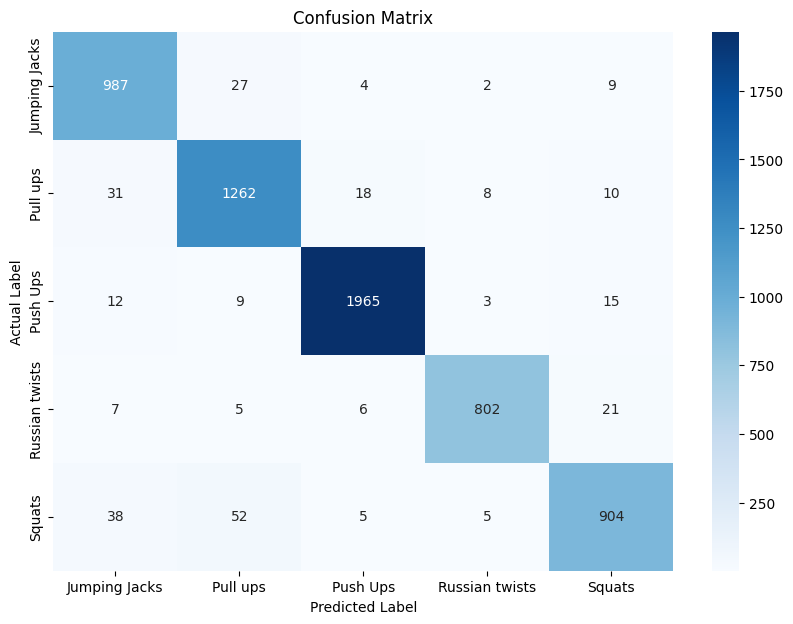

In [17]:
predictions = model.predict(exercise_predictors_test)
exercise_categories_predicted = np.argmax(predictions, axis=1)

cm = confusion_matrix(exercise_categories_test, exercise_categories_predicted)

plt.figure(figsize = (10, 7))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
print("Classification Report:\n", classification_report(exercise_categories_test, exercise_categories_predicted, target_names = label_encoder.classes_))

Classification Report:
                 precision    recall  f1-score   support

 Jumping Jacks       0.92      0.96      0.94      1029
      Pull ups       0.93      0.95      0.94      1329
      Push Ups       0.98      0.98      0.98      2004
Russian twists       0.98      0.95      0.97       841
        Squats       0.94      0.90      0.92      1004

      accuracy                           0.95      6207
     macro avg       0.95      0.95      0.95      6207
  weighted avg       0.95      0.95      0.95      6207

